<a href="https://colab.research.google.com/github/nifredman/BoseHubbardSimulations/blob/main/SDMFT3D_version_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Omega: 57.844738037224786 Hz


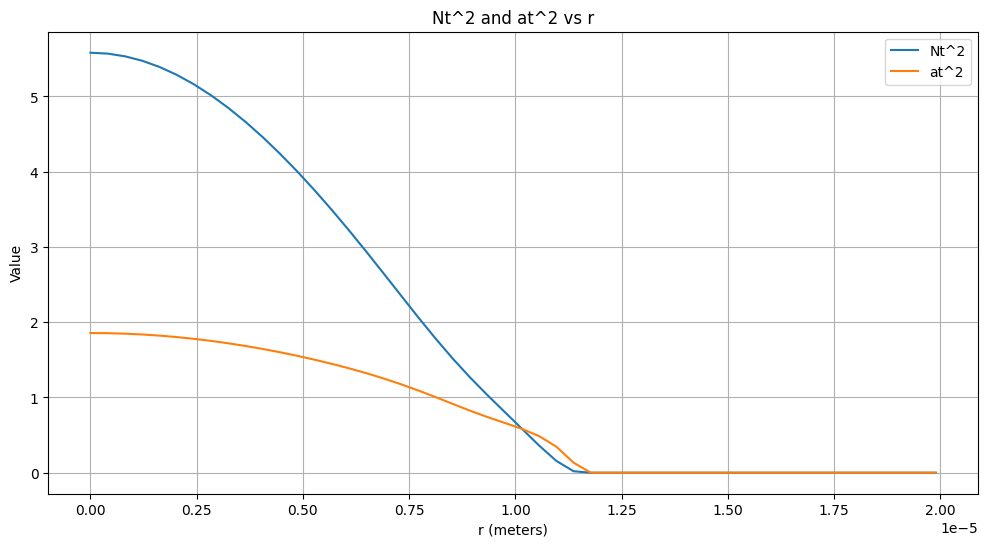

In [ ]:
import numpy as np
from scipy.linalg import eigh
from scipy.interpolate import interp1d
from scipy.optimize import root
import matplotlib.pyplot as plt

# Define constants
omega_0 = 2 * np.pi * 53  # Dipole trap frequency in rad/s
m = 87 * 1.67e-27  # Mass in kg
hbar = 1.055e-34  # Reduced Planck's constant in J*s
d = 812e-9 / 2  # Lattice spacing in meters
ER = (hbar**2 * np.pi**2) / (2 * m * d**2)  # Recoil energy in Joules
kb = 1.38e-23  # Boltzmann constant in J/K

# Lattice depth in units of recoil energy
s = 10  # Lattice depth, 10 times the recoil energy

# Calculate Omega using the provided formula
trap_frequency_term1 = (4 * ER) / (m * (120e-6)**2)
trap_frequency_term2 = (s / np.sqrt(2)) - np.sqrt(s / 2)
omega = np.sqrt(trap_frequency_term1 * trap_frequency_term2 + omega_0**2)
omega_hz = omega / (2 * np.pi)  # Convert to Hz

print(f"Omega: {omega_hz} Hz")

# Define hopping amplitude t and interaction strength U based on lattice depth s
t = ER * (4/np.sqrt(np.pi)) * (s**(3/4)) * np.exp(-2*np.sqrt(s))  # Hopping amplitude
U = s * ER  # On-site interaction energy

def H(t, U, mu, a):
    z = 6
    size = 11
    H_matrix = np.zeros((size, size))

    for i in range(size):
        for j in range(size):
            H_matrix[i, j] = (U / 2 * i * (i - 1) - mu * i + z * t * a**2) * (i == j) - \
                             z * t * a * ((i + 1 == j) * np.sqrt(j) + (i == j + 1) * np.sqrt(i))

    return H_matrix

def at(t, U, mu, T):
    a = 0.1
    ap = 0.3

    while abs(ap - a) > 1e-3:
        a = ap
        H_matrix = H(t, U, mu, a)
        vals, states = eigh(H_matrix)
        epsilon = vals

        numerator = 0
        denominator = 0
        for i in range(11):
            for j in range(1, 11):
                numerator += np.sqrt(j) * states[j, i] * states[j-1, i] * np.exp(-epsilon[i] / T)
            denominator += np.exp(-epsilon[i] / T)

        ap = numerator / denominator

    return ap

def ct(t, U, mu, T):
    optimal_a = at(t, U, mu, T)
    H_matrix = H(t, U, mu, optimal_a)
    vals, states = eigh(H_matrix)

    # Ordering the eigenvalues
    sorted_indices = np.argsort(vals)

    # Returning the sorted eigenvectors
    sorted_eigenvectors = states[:, sorted_indices]

    return sorted_eigenvectors

def nt(t, U, mu, T):
    sorted_eigenvectors = ct(t, U, mu, T)

    # Define the vector b as [0, 1, 2, ..., 10]
    b = np.array([i for i in range(11)])

    # Compute the dot product of b with the square of each column
    result = np.array([np.dot(b, col**2) for col in sorted_eigenvectors.T])

    return result

def epsilon_t(t, U, mu, T):
    optimal_a = at(t, U, mu, T)
    H_matrix = H(t, U, mu, optimal_a)
    vals, states = eigh(H_matrix)

    # Sorting the eigenvalues
    sorted_vals = np.sort(vals)

    return sorted_vals

def Zt(t, U, mu, T):
    epsilon = epsilon_t(t, U, mu, T)

    partition_function = np.sum(np.exp(-epsilon / T))

    return partition_function

def Nt(t, U, mu, T):
    n_t = nt(t, U, mu, T)
    epsilon = epsilon_t(t, U, mu, T)
    Z = Zt(t, U, mu, T)

    result = np.dot(n_t, np.exp(-epsilon / T)) / Z

    return result

def Ut(t, U, mu, T):
    epsilon = epsilon_t(t, U, mu, T)
    Z = Zt(t, U, mu, T)

    result = np.dot(epsilon, np.exp(-epsilon / T)) / Z

    return result

def St(t, U, mu, T):
    Z = Zt(t, U, mu, T)
    U_t = Ut(t, U, mu, T)

    entropy = np.log(Z) + U_t / T

    return entropy

def n0t(t, U, mu, T):
    x = nt(t, U, mu, T)[0]
    if x > 0.01:
        return at(t, U, mu, T)**2 / x
    else:
        return 0

def nn(t, U, mu, T):
    dr = d
    r_values = np.arange(0, 20e-6, dr)
    sum_value = 0

    for r in r_values:
        effective_mu = mu - (0.5 * m * omega**2 * r**2) / ER
        sum_value += r**2 * Nt(t, U, effective_mu, T)

    result = (4 * np.pi * dr * sum_value) / d**3
    return result

def mu_func(t, U, T, num):
    def nn_interp(mu):
        return nn(t, U, mu, T)

    mu_values = np.arange(-0.3, 1.1, 0.2)
    nn_values = [nn_interp(mu) for mu in mu_values]

    interp_func = interp1d(mu_values, nn_values, kind='cubic')

    def equation(mu):
        return interp_func(mu) - num

    result = root(equation, 0.1)
    return result.x[0]

def S_total(t, U, T, num):
    dr = d
    r_values = np.arange(0, 20e-6, dr)
    sum_value = 0

    mu = mu_func(t, U, T, num)
    for r in r_values:
        effective_mu = mu - (0.5 * m * omega**2 * r**2) / ER
        sum_value += r**2 * St(t, U, effective_mu, T)

    result = (4 * np.pi * dr * sum_value) / d**3
    return result

def frac(t, U, T, num):
    dr = d
    r_values = np.arange(0, 20e-6, dr)
    sum_value = 0

    mu = mu_func(t, U, T, num)
    for r in r_values:
        effective_mu = mu - (0.5 * m * omega**2 * r**2) / ER
        sum_value += r**2 * at(t, U, effective_mu, T)**2

    result = (4 * np.pi * dr * sum_value) / d**3 / nn(t, U, mu, T)
    return result

def en(t, U, T, num):
    dr = d
    r_values = np.arange(0, 20e-6, dr)
    sum_value = 0

    mu = mu_func(t, U, T, num)
    for r in r_values:
        effective_mu = mu - (0.5 * m * omega**2 * r**2) / ER
        sum_value += r**2 * Ut(t, U, effective_mu, T)

    result = (4 * np.pi * dr * sum_value) / d**3
    return result

# Example usage
T = 0.0125
t = 0.019
U = 0.28
num = 105 * 10**3
mu_result = mu_func(t, U, T, num)
mu = mu_result

nt_result = nt(t, U, mu, T)
epsilon_result = epsilon_t(t, U, mu, T)
Z_result = Zt(t, U, mu, T)
N_result = Nt(t, U, mu, T)
U_result = Ut(t, U, mu, T)
S_result = St(t, U, mu, T)
n0t_result = n0t(t, U, mu, T)
nn_result = nn(t, U, mu, T)
S_total_result = S_total(t, U, T, num)
frac_result = frac(t, U, T, num)
en_result = en(t, U, T, num)

dr = d
r_values = np.arange(0, 20e-6, dr)

# Calculate Nt and at squared for each r in r_values
Nt_squared = [Nt(t, U, mu - (0.5 * m * omega**2 * r**2) / ER, T)**2 for r in r_values]
at_squared = [at(t, U, mu - (0.5 * m * omega**2 * r**2) / ER, T)**2 for r in r_values]

# Plot the results
plt.figure(figsize=(12, 6))

plt.plot(r_values, Nt_squared, label='Nt^2')
plt.plot(r_values, at_squared, label='at^2')

plt.xlabel('r (meters)')
plt.ylabel('Value')
plt.title('Nt^2 and at^2 vs r')
plt.legend()
plt.grid(True)

plt.show()


Omega: 78.49849500847235 Hz


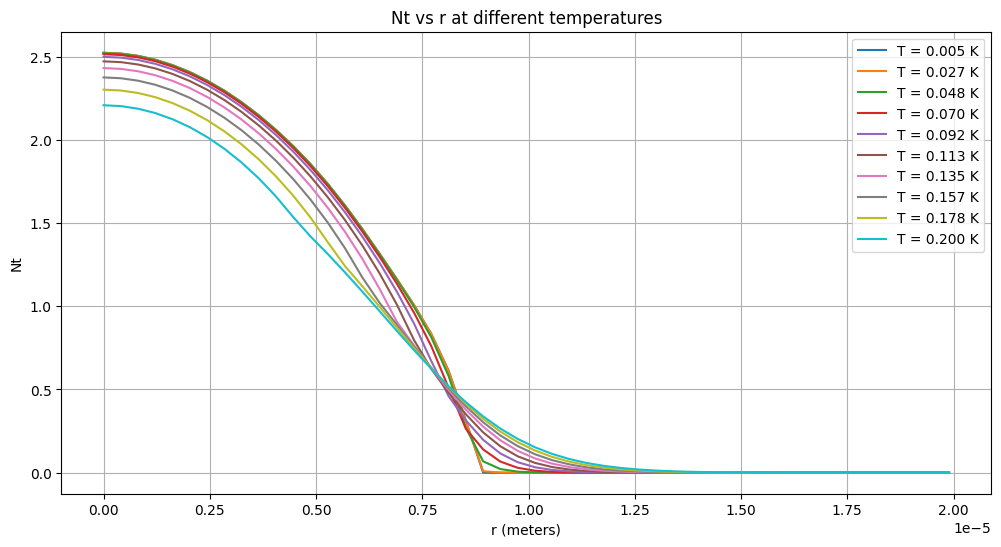

In [ ]:
import numpy as np
from scipy.linalg import eigh
from scipy.interpolate import interp1d
from scipy.optimize import root
import matplotlib.pyplot as plt
from scipy.optimize import root, root_scalar


# Define constants
omega_0 = 2 * np.pi * 75  # Dipole trap frequency in rad/s
m = 87 * 1.67e-27  # Mass in kg
hbar = 1.055e-34  # Reduced Planck's constant in J*s
d = 812e-9 / 2  # Lattice spacing in meters
ER = (hbar**2 * np.pi**2) / (2 * m * d**2)  # Recoil energy in Joules
kb = 1.38e-23  # Boltzmann constant in J/K

# Lattice depth in units of recoil energy
s = 10

# Values
t = 0.019
U = 0.28
num = 50 * 10**3

# Calculate Omega using the provided formula
trap_frequency_term1 = (4 * ER) / (m * (120e-6)**2)
trap_frequency_term2 = (s / np.sqrt(2)) - np.sqrt(s / 2)
omega = np.sqrt(trap_frequency_term1 * trap_frequency_term2 + omega_0**2)
omega_hz = omega / (2 * np.pi)  # Convert to Hz

print(f"Omega: {omega_hz} Hz")


def H(t, U, mu, a):
    z = 6
    size = 11
    H_matrix = np.zeros((size, size))

    for i in range(size):
        for j in range(size):
            H_matrix[i, j] = (U / 2 * i * (i - 1) - mu * i + z * t * a**2) * (i == j) - \
                             z * t * a * ((i + 1 == j) * np.sqrt(j) + (i == j + 1) * np.sqrt(i))

    return H_matrix

def at(t, U, mu, T):
    a = 0.1
    ap = 0.3

    while abs(ap - a) > 1e-3:
        a = ap
        H_matrix = H(t, U, mu, a)
        vals, states = eigh(H_matrix)
        epsilon = vals

        numerator = 0
        denominator = 0
        for i in range(11):
            for j in range(1, 11):
                numerator += np.sqrt(j) * states[j, i] * states[j-1, i] * np.exp(-epsilon[i] / T)
            denominator += np.exp(-epsilon[i] / T)

        ap = numerator / denominator

    return ap

def ct(t, U, mu, T):
    optimal_a = at(t, U, mu, T)
    H_matrix = H(t, U, mu, optimal_a)
    vals, states = eigh(H_matrix)

    # Ordering the eigenvalues
    sorted_indices = np.argsort(vals)

    # Returning the sorted eigenvectors
    sorted_eigenvectors = states[:, sorted_indices]

    return sorted_eigenvectors

def nt(t, U, mu, T):
    sorted_eigenvectors = ct(t, U, mu, T)

    # Define the vector b as [0, 1, 2, ..., 10]
    b = np.array([i for i in range(11)])

    # Compute the dot product of b with the square of each column
    result = np.array([np.dot(b, col**2) for col in sorted_eigenvectors.T])

    return result

def epsilon_t(t, U, mu, T):
    optimal_a = at(t, U, mu, T)
    H_matrix = H(t, U, mu, optimal_a)
    vals, states = eigh(H_matrix)

    # Sorting the eigenvalues
    sorted_vals = np.sort(vals)

    return sorted_vals

def Zt(t, U, mu, T):
    epsilon = epsilon_t(t, U, mu, T)

    partition_function = np.sum(np.exp(-epsilon / T))

    return partition_function

def Nt(t, U, mu, T):
    n_t = nt(t, U, mu, T)
    epsilon = epsilon_t(t, U, mu, T)
    Z = Zt(t, U, mu, T)

    result = np.dot(n_t, np.exp(-epsilon / T)) / Z

    return result

def Ut(t, U, mu, T):
    epsilon = epsilon_t(t, U, mu, T)
    Z = Zt(t, U, mu, T)

    result = np.dot(epsilon, np.exp(-epsilon / T)) / Z

    return result

def St(t, U, mu, T):
    Z = Zt(t, U, mu, T)
    U_t = Ut(t, U, mu, T)

    entropy = np.log(Z) + U_t / T

    return entropy

def n0t(t, U, mu, T):
    x = nt(t, U, mu, T)[0]
    if x > 0.01:
        return at(t, U, mu, T)**2 / x
    else:
        return 0

def nn(t, U, mu, T):
    dr = d
    r_values = np.arange(0, 20e-6, dr)
    sum_value = 0

    for r in r_values:
        effective_mu = mu - (0.5 * m * omega**2 * r**2) / ER
        sum_value += r**2 * Nt(t, U, effective_mu, T)

    result = (4 * np.pi * dr * sum_value) / d**3
    return result

def mu_func(t, U, T, num,
            mu0=0.1, step=0.2, max_expand=50):
    """
    Solve nn(t,U,mu,T) = num for mu using a bracketed root finder.
    Expands the bracket until it finds a sign change.
    """

    def f(mu):
        return nn(t, U, mu, T) - num

    # Start with a small bracket around mu0
    lo = mu0 - step
    hi = mu0 + step
    flo = f(lo)
    fhi = f(hi)

    # Expand until sign change or until we give up
    k = 0
    while flo * fhi > 0 and k < max_expand:
        k += 1
        lo -= step
        hi += step
        flo = f(lo)
        fhi = f(hi)

    if flo * fhi > 0:
        raise RuntimeError(
            f"Could not bracket root for mu after expanding to [{lo}, {hi}]. "
            f"f(lo)={flo}, f(hi)={fhi}. "
            "Increase max_expand/step or check monotonicity / target num."
        )

    sol = root_scalar(f, bracket=[lo, hi], method="brentq")
    return sol.root

def S_total(t, U, T, num):
    dr = d
    r_values = np.arange(0, 20e-6, dr)
    sum_value = 0

    mu = mu_func(t, U, T, num)
    for r in r_values:
        effective_mu = mu - (0.5 * m * omega**2 * r**2) / ER
        sum_value += r**2 * St(t, U, effective_mu, T)

    result = (4 * np.pi * dr * sum_value) / d**3
    return result

def frac(t, U, T, num):
    dr = d
    r_values = np.arange(0, 20e-6, dr)
    sum_value = 0

    mu = mu_func(t, U, T, num)
    for r in r_values:
        effective_mu = mu - (0.5 * m * omega**2 * r**2) / ER
        sum_value += r**2 * at(t, U, effective_mu, T)**2

    result = (4 * np.pi * dr * sum_value) / d**3 / nn(t, U, mu, T)
    return result

def en(t, U, T, num):
    dr = d
    r_values = np.arange(0, 20e-6, dr)
    sum_value = 0

    mu = mu_func(t, U, T, num)
    for r in r_values:
        effective_mu = mu - (0.5 * m * omega**2 * r**2) / ER
        sum_value += r**2 * Ut(t, U, effective_mu, T)

    result = (4 * np.pi * dr * sum_value) / d**3
    return result

dr = d
r_values = np.arange(0, 20e-6, dr)

# Define a range of temperatures
temperatures = np.linspace(0.005, 0.2, 10)

plt.figure(figsize=(12, 6))

for T in temperatures:
    mu = mu_func(t, U, T, num)
    Nt_values = [Nt(t, U, mu - (0.5 * m * omega**2 * r**2) / ER, T) for r in r_values]
    plt.plot(r_values, Nt_values, label=f'T = {T:.3f} K')

plt.xlabel('r (meters)')
plt.ylabel('Nt')
plt.title('Nt vs r at different temperatures')
plt.legend()
plt.grid(True)
plt.show()



Omega: 64.319621567568 Hz
T = 0.05 nK  ->  T_ER = 0.0003009 (in units of ER)
mu0 (in ER units) = 0.424502328726899

Normalized Gaussian width from Nt(r)/Nt(0):
  sigma = 6.570 µm
  FWHM  = 15.472 µm


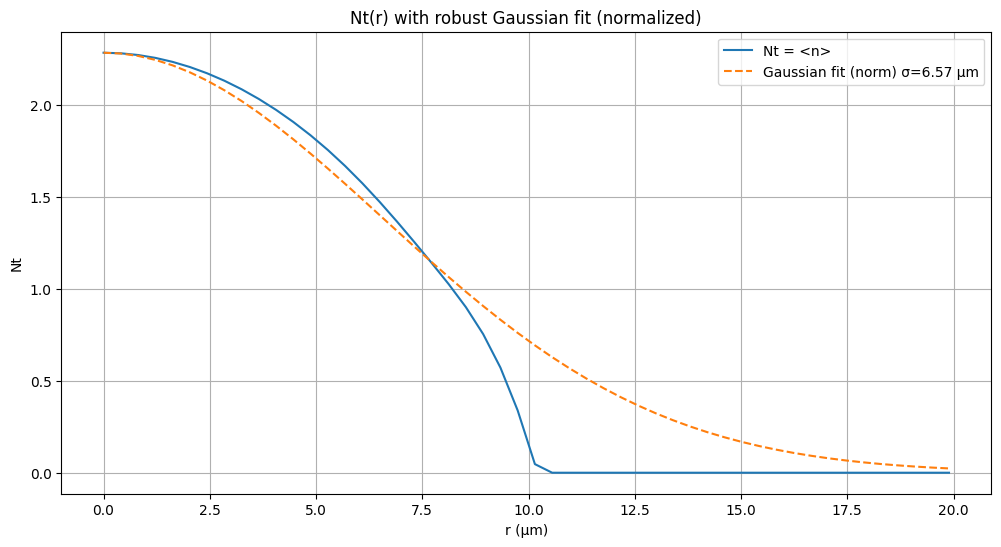

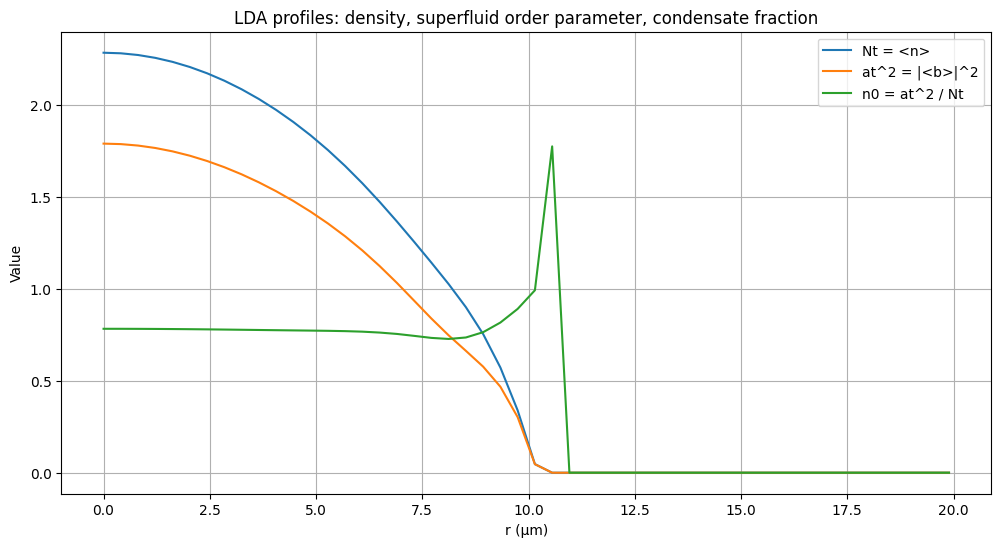

Central filling = 2.2864541017016236


In [ ]:
import numpy as np
from scipy.linalg import eigh
from scipy.interpolate import interp1d
from scipy.optimize import root
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# ------------------------
# Physical constants (SI)
# ------------------------
omega_0 = 2 * np.pi * 60        # rad/s
m = 87 * 1.67e-27              # kg (Rb-87 approx)
hbar = 1.055e-34               # J*s
d = 812e-9 / 2                 # m (lattice spacing)
kb = 1.38e-23                  # J/K

# Recoil energy (J)
ER_J = (hbar**2 * np.pi**2) / (2 * m * d**2)

# Lattice depth (dimensionless, in ER)
s = 10

# Trap frequency correction (keep as you had it; omega is rad/s)
trap_frequency_term1 = (4 * ER_J) / (m * (120e-6)**2)
trap_frequency_term2 = (s / np.sqrt(2)) - np.sqrt(s / 2)
omega = np.sqrt(trap_frequency_term1 * trap_frequency_term2 + omega_0**2)
omega_hz = omega / (2 * np.pi)
print(f"Omega: {omega_hz} Hz")

# ------------------------------------------------------
# IMPORTANT: Bose-Hubbard energies are in units of ER
# ------------------------------------------------------
# (You can still compute rough ER-based estimates, but you later overwrite t,U anyway.)
# Here we will USE dimensionless t, U, mu consistently.

def H(t, U, mu, a):
    z = 6
    size = 11
    H_matrix = np.zeros((size, size))

    for i in range(size):
        # diagonal
        H_matrix[i, i] = (U / 2 * i * (i - 1) - mu * i + z * t * a**2)

        # off-diagonals
        if i + 1 < size:
            j = i + 1
            H_matrix[i, j] = -z * t * a * np.sqrt(j)
            H_matrix[j, i] = -z * t * a * np.sqrt(j)

    return H_matrix

def at(t, U, mu, T_ER):
    """
    Self-consistent mean-field order parameter a = <b>.
    T_ER is dimensionless temperature in units of ER: T_ER = kB*T_K / ER_J
    """
    a = 0.1
    ap = 0.3

    while abs(ap - a) > 1e-3:
        a = ap
        H_matrix = H(t, U, mu, a)
        vals, states = eigh(H_matrix)

        # For numerical stability, shift energies by min(vals) (doesn't change probabilities)
        eps = vals - np.min(vals)

        numerator = 0.0
        denominator = 0.0

        # Thermal weights
        w = np.exp(-eps / T_ER)

        for i in range(11):      # eigenstate index
            # <b> in eigenstate i
            bi = 0.0
            for j in range(1, 11):
                bi += np.sqrt(j) * states[j, i] * states[j-1, i]
            numerator += bi * w[i]
            denominator += w[i]

        ap = numerator / denominator

    return ap

def ct(t, U, mu, T_ER):
    a_opt = at(t, U, mu, T_ER)
    vals, states = eigh(H(t, U, mu, a_opt))
    idx = np.argsort(vals)
    return vals[idx], states[:, idx]

def Nt(t, U, mu, T_ER):
    """
    Mean filling <n> at a given (t,U,mu,T).
    """
    vals, vecs = ct(t, U, mu, T_ER)

    eps = vals - np.min(vals)
    w = np.exp(-eps / T_ER)
    Z = np.sum(w)

    n_basis = np.arange(11)  # [0..10]

    # <n> in each eigenstate i is sum_n n |<n|psi_i>|^2
    n_i = np.array([np.dot(n_basis, vecs[:, i]**2) for i in range(11)])

    return np.dot(n_i, w) / Z

def Ut(t, U, mu, T_ER):
    vals, vecs = ct(t, U, mu, T_ER)
    eps = vals - np.min(vals)
    w = np.exp(-eps / T_ER)
    Z = np.sum(w)

    # Note: this returns the thermal mean of (shifted) eigenvalues + min(vals).
    # That constant shift doesn't matter for derivatives, but if you care about absolute U_t,
    # include min(vals) back.
    return (np.dot(eps + np.min(vals), w) / Z)

def St(t, U, mu, T_ER):
    vals, vecs = ct(t, U, mu, T_ER)
    eps = vals - np.min(vals)
    w = np.exp(-eps / T_ER)
    Z = np.sum(w)

    U_t = (np.dot(eps, w) / Z)  # internal energy in shifted convention
    return np.log(Z) + U_t / T_ER

def nn(t, U, mu0, T_ER):
    """
    Total atom number integral using LDA with spherical weighting 4π r^2.
    mu(r) = mu0 - (1/2 m ω^2 r^2)/ER
    """
    dr = d
    r_values = np.arange(0, 20e-6, dr)

    total = 0.0
    for r in r_values:
        mu_r = mu0 - (0.5 * m * omega**2 * r**2) / ER_J   # dimensionless in ER
        total += r**2 * Nt(t, U, mu_r, T_ER)

    return (4 * np.pi * dr * total) / d**3

def mu_func(t, U, T_ER, num):
    def nn_mu(mu):
        return nn(t, U, mu, T_ER)

    mu_values = np.arange(-0.3, 1.1, 0.2)
    nn_values = [nn_mu(mu) for mu in mu_values]

    interp_func = interp1d(mu_values, nn_values, kind='cubic', fill_value="extrapolate")

    def equation(mu):
        return interp_func(mu) - num

    result = root(equation, 0.1)
    return result.x[0]

def n0_local(t, U, mu, T_ER):
    """
    Local condensate fraction proxy n0(r) = a^2 / <n>.
    """
    n = Nt(t, U, mu, T_ER)
    if n > 1e-6:
        a = at(t, U, mu, T_ER)
        return (a**2) / n
    return 0.0

  # -------------------------
# Gaussian fit helpers
# -------------------------
def gauss_centered(r_um, A, sigma_um, C):
    """Gaussian centered at r=0."""
    return A * np.exp(-(r_um**2) / (2 * sigma_um**2)) + C

def gauss_offset(r_um, A, r0_um, sigma_um, C):
    """Gaussian with free center r0."""
    return A * np.exp(-((r_um - r0_um)**2) / (2 * sigma_um**2)) + C


# -------------------------
# Example parameters
# -------------------------
t = 0.019         # in ER
U = 0.28       # in ER
num = 70 * 10**3

# Specify temperature in nK (change this to what you want)
T_nK = 0.05
T_K = T_nK * 1e-9

# Convert Kelvin to ER units:
T_ER = (kb * T_K) / ER_J
print(f"T = {T_nK} nK  ->  T_ER = {T_ER:.4g} (in units of ER)")

# Solve for mu0 given desired number
mu0 = mu_func(t, U, T_ER, num)
print(f"mu0 (in ER units) = {mu0}")

# -------------------------
# Build radial profiles
# -------------------------
dr = d
r_values = np.arange(0, 20e-6, dr)

Nt_vals = []
a2_vals = []
n0_vals = []

for r in r_values:
    mu_r = mu0 - (0.5 * m * omega**2 * r**2) / ER_J
    n = Nt(t, U, mu_r, T_ER)
    a = at(t, U, mu_r, T_ER)

    Nt_vals.append(n)
    a2_vals.append(a**2)
    n0_vals.append((a**2 / n) if n > 1e-6 else 0.0)
# -------------------------
# Robust Gaussian width from normalized Nt(r)
# -------------------------
r_um = r_values * 1e6
Nt_arr = np.array(Nt_vals, dtype=float)

# Normalize to center (or max)
N0 = Nt_arr[0]  # since r starts at 0
if N0 <= 0:
    raise ValueError("Nt(0) is non-positive; cannot normalize.")

y = Nt_arr / N0

# Only fit where signal is meaningful (avoid tail + numerical noise)
mask = (y > 0.2) & (r_um < 20)   # keep inner part; adjust 0.2 if desired
r_fit = r_um[mask]
y_fit = y[mask]

def gauss_norm(r_um, sigma_um):
    return np.exp(-(r_um**2) / (2 * sigma_um**2))

# Initial guess: where y ~ exp(-1/2) ~ 0.607 occurs near r ~ sigma
# crude: pick r where y closest to 0.607
target = np.exp(-0.5)
sigma0 = r_fit[np.argmin(np.abs(y_fit - target))] if len(r_fit) > 5 else 5.0

popt, pcov = curve_fit(
    gauss_norm, r_fit, y_fit,
    p0=[sigma0],
    bounds=([0.1], [50.0]),   # sigma between 0.1 and 50 µm
    maxfev=20000
)

sigma_um = popt[0]
fwhm_um = 2*np.sqrt(2*np.log(2))*sigma_um

print(f"\nNormalized Gaussian width from Nt(r)/Nt(0):")
print(f"  sigma = {sigma_um:.3f} µm")
print(f"  FWHM  = {fwhm_um:.3f} µm")

# Plot the fit on top of Nt
plt.figure(figsize=(12,6))
plt.plot(r_um, Nt_arr, label="Nt = <n>")
plt.plot(r_um, N0*gauss_norm(r_um, sigma_um), '--', label=f"Gaussian fit (norm) σ={sigma_um:.2f} µm")
plt.xlabel("r (µm)")
plt.ylabel("Nt")
plt.title("Nt(r) with robust Gaussian fit (normalized)")
plt.grid(True)
plt.legend()
plt.show()


# -------------------------
# Plot: Nt, a^2, n0
# -------------------------
plt.figure(figsize=(12, 6))
plt.plot(r_values * 1e6, Nt_vals, label='Nt = <n>')
plt.plot(r_values * 1e6, a2_vals, label='at^2 = |<b>|^2')
plt.plot(r_values * 1e6, n0_vals, label='n0 = at^2 / Nt')

plt.xlabel('r (µm)')
plt.ylabel('Value')
plt.title('LDA profiles: density, superfluid order parameter, condensate fraction')
plt.legend()
plt.grid(True)
plt.show()
print("Central filling =", Nt(t, U, mu0, T_ER))



In [ ]:
import numpy as np
from scipy.linalg import eigh
from scipy.interpolate import interp1d
from scipy.optimize import root
import matplotlib.pyplot as plt

# Define constants
omega_0 = 2 * np.pi * 53  # Dipole trap frequency in rad/s
m = 87 * 1.67e-27  # Mass in kg
hbar = 1.055e-34  # Reduced Planck's constant in J*s
d = 812e-9 / 2  # Lattice spacing in meters
ER = (hbar**2 * np.pi**2) / (2 * m * d**2)  # Recoil energy in Joules
kb = 1.38e-23  # Boltzmann constant in J/K

# Calculate Omega using the provided formula
s = 10  # Lattice depth
trap_frequency_term1 = (4 * ER) / (m * (120e-6)**2)
trap_frequency_term2 = (s / np.sqrt(2)) - np.sqrt(s / 2)
omega = np.sqrt(trap_frequency_term1 * trap_frequency_term2 + omega_0**2)
omega_hz = omega / (2 * np.pi)  # Convert to Hz

print(f"Omega: {omega_hz} Hz")

def H(t, U, mu, a):
    z = 6
    size = 11
    H_matrix = np.zeros((size, size))

    for i in range(size):
        for j in range(size):
            H_matrix[i, j] = (U / 2 * i * (i - 1) - mu * i + z * t * a**2) * (i == j) - \
                             z * t * a * ((i + 1 == j) * np.sqrt(j) + (i == j + 1) * np.sqrt(i))

    return H_matrix

def at(t, U, mu, T):
    a = 0.1
    ap = 0.3

    while abs(ap - a) > 1e-3:
        a = ap
        H_matrix = H(t, U, mu, a)
        vals, states = eigh(H_matrix)
        epsilon = vals

        numerator = 0
        denominator = 0
        for i in range(11):
            for j in range(1, 11):
                numerator += np.sqrt(j) * states[j, i] * states[j-1, i] * np.exp(-epsilon[i] / T)
            denominator += np.exp(-epsilon[i] / T)

        ap = numerator / denominator

    return ap

def ct(t, U, mu, T):
    optimal_a = at(t, U, mu, T)
    H_matrix = H(t, U, mu, optimal_a)
    vals, states = eigh(H_matrix)

    # Ordering the eigenvalues
    sorted_indices = np.argsort(vals)

    # Returning the sorted eigenvectors
    sorted_eigenvectors = states[:, sorted_indices]

    return sorted_eigenvectors

def nt(t, U, mu, T):
    sorted_eigenvectors = ct(t, U, mu, T)

    # Define the vector b as [0, 1, 2, ..., 10]
    b = np.array([i for i in range(11)])

    # Compute the dot product of b with the square of each column
    result = np.array([np.dot(b, col**2) for col in sorted_eigenvectors.T])

    return result

def epsilon_t(t, U, mu, T):
    optimal_a = at(t, U, mu, T)
    H_matrix = H(t, U, mu, optimal_a)
    vals, states = eigh(H_matrix)

    # Sorting the eigenvalues
    sorted_vals = np.sort(vals)

    return sorted_vals

def Zt(t, U, mu, T):
    epsilon = epsilon_t(t, U, mu, T)

    partition_function = np.sum(np.exp(-epsilon / T))

    return partition_function

def Nt(t, U, mu, T):
    n_t = nt(t, U, mu, T)
    epsilon = epsilon_t(t, U, mu, T)
    Z = Zt(t, U, mu, T)

    result = np.dot(n_t, np.exp(-epsilon / T)) / Z

    return result

def Ut(t, U, mu, T):
    epsilon = epsilon_t(t, U, mu, T)
    Z = Zt(t, U, mu, T)

    result = np.dot(epsilon, np.exp(-epsilon / T)) / Z

    return result

def St(t, U, mu, T):
    Z = Zt(t, U, mu, T)
    U_t = Ut(t, U, mu, T)

    entropy = np.log(Z) + U_t / T

    return entropy

def n0t(t, U, mu, T):
    x = nt(t, U, mu, T)[0]
    if x > 0.01:
        return at(t, U, mu, T)**2 / x
    else:
        return 0

def V(x, y, z):
    return (0.5 * m * omega**2 * (x**2 + y**2 + z**2)) / ER

def nn(t, U, mu, T):
    dr = 5 * d  # Increased step size to reduce number of points
    r_values = np.arange(0, 20e-6, dr)
    sum_value = 0

    for x in r_values:
        for y in r_values:
            for z in r_values:
                effective_mu = mu - V(x, y, z)
                sum_value += Nt(t, U, effective_mu, T)

    result = sum_value / d**3
    return result

def mu_func(t, U, T, num):
    def nn_interp(mu):
        return nn(t, U, mu, T)

    mu_values = np.arange(-0.3, 1.1, 0.2)
    nn_values = [nn_interp(mu) for mu in mu_values]

    interp_func = interp1d(mu_values, nn_values, kind='cubic')

    def equation(mu):
        return interp_func(mu) - num

    result = root(equation, 0.1)
    return result.x[0]

def S_total(t, U, T, num):
    dr = 5 * d  # Increased step size to reduce number of points
    r_values = np.arange(0, 20e-6, dr)
    sum_value = 0

    mu = mu_func(t, U, T, num)
    for x in r_values:
        for y in r_values:
            for z in r_values:
                effective_mu = mu - V(x, y, z)
                sum_value += St(t, U, effective_mu, T)

    result = sum_value / d**3
    return result

def frac(t, U, T, num):
    dr = 5 * d  # Increased step size to reduce number of points
    r_values = np.arange(0, 20e-6, dr)
    sum_value = 0

    mu = mu_func(t, U, T, num)
    for x in r_values:
        for y in r_values:
            for z in r_values:
                effective_mu = mu - V(x, y, z)
                sum_value += at(t, U, effective_mu, T)**2

    result = sum_value / d**3 / nn(t, U, mu, T)
    return result

def en(t, U, T, num):
    dr = 5 * d  # Increased step size to reduce number of points
    r_values = np.arange(0, 20e-6, dr)
    sum_value = 0

    mu = mu_func(t, U, T, num)
    for x in r_values:
        for y in r_values:
            for z in r_values:
                effective_mu = mu - V(x, y, z)
                sum_value += Ut(t, U, effective_mu, T)

    result = sum_value / d**3
    return result

# Example usage
T = 0.000125
t = 0.019
U = 0.28
num = 105 * 10**3
mu_result = mu_func(t, U, T, num)
mu = mu_result

# Calculate Nt and at squared for each (x, y, z) in r_values
r_values = np.arange(0, 20e-6, 5 * d)  # Increased step size to reduce number of points
Nt_squared = np.zeros((len(r_values), len(r_values), len(r_values)))
at_squared = np.zeros((len(r_values), len(r_values), len(r_values)))

for i, x in enumerate(r_values):
    for j, y in enumerate(r_values):
        for k, z in enumerate(r_values):
            effective_mu = mu - V(x, y, z)
            Nt_squared[i, j, k] = Nt(t, U, effective_mu, T)**2
            at_squared[i, j, k] = at(t, U, effective_mu, T)**2

# Plot the results
from mpl_toolkits.mplot3d import Axes3D

X, Y, Z = np.meshgrid(r_values, r_values, r_values)
fig = plt.figure(figsize=(12, 6))

print(mu)

# Plot for Nt^2
ax1 = fig.add_subplot(121, projection='3d')
scat1 = ax1.scatter(X.flatten(), Y.flatten(), Z.flatten(), c=Nt_squared.flatten(), cmap='viridis')
ax1.set_title('Nt^2 vs (x, y, z)')
ax1.set_xlabel('x (meters)')
ax1.set_ylabel('y (meters)')
ax1.set_zlabel('z (meters)')
fig.colorbar(scat1, ax=ax1, label='Nt^2')

# Plot for at^2
ax2 = fig.add_subplot(122, projection='3d')
scat2 = ax2.scatter(X.flatten(), Y.flatten(), Z.flatten(), c=at_squared.flatten(), cmap='plasma')
ax2.set_title('at^2 vs (x, y, z)')
ax2.set_xlabel('x (meters)')
ax2.set_ylabel('y (meters)')
ax2.set_zlabel('z (meters)')
fig.colorbar(scat2, ax=ax2, label='at^2')

plt.show()


Omega: 57.844738037224786 Hz


<ipython-input-1-326a58b519f0>:50: RuntimeWarning: overflow encountered in exp
  numerator += np.sqrt(j) * states[j, i] * states[j-1, i] * np.exp(-epsilon[i] / T)
<ipython-input-1-326a58b519f0>:51: RuntimeWarning: overflow encountered in exp
  denominator += np.exp(-epsilon[i] / T)
<ipython-input-1-326a58b519f0>:53: RuntimeWarning: invalid value encountered in scalar divide
  ap = numerator / denominator


ValueError: array must not contain infs or NaNs

Omega: 86.17432168920834 Hz


<ipython-input-5-b6f2ba71b238>:54: RuntimeWarning: overflow encountered in exp
  numerator += np.sqrt(j) * states[j, i] * states[j-1, i] * np.exp(-epsilon[i] / T)
<ipython-input-5-b6f2ba71b238>:55: RuntimeWarning: overflow encountered in exp
  denominator += np.exp(-epsilon[i] / T)
<ipython-input-5-b6f2ba71b238>:61: RuntimeWarning: invalid value encountered in scalar divide
  ap = numerator / denominator
<ipython-input-5-b6f2ba71b238>:102: RuntimeWarning: overflow encountered in exp
  partition_function = np.sum(np.exp(-epsilon / T))
<ipython-input-5-b6f2ba71b238>:111: RuntimeWarning: overflow encountered in exp
  result = np.dot(n_t, np.exp(-epsilon / T)) / Z
<ipython-input-5-b6f2ba71b238>:111: RuntimeWarning: invalid value encountered in scalar divide
  result = np.dot(n_t, np.exp(-epsilon / T)) / Z
<ipython-input-5-b6f2ba71b238>:54: RuntimeWarning: invalid value encountered in scalar add
  numerator += np.sqrt(j) * states[j, i] * states[j-1, i] * np.exp(-epsilon[i] / T)


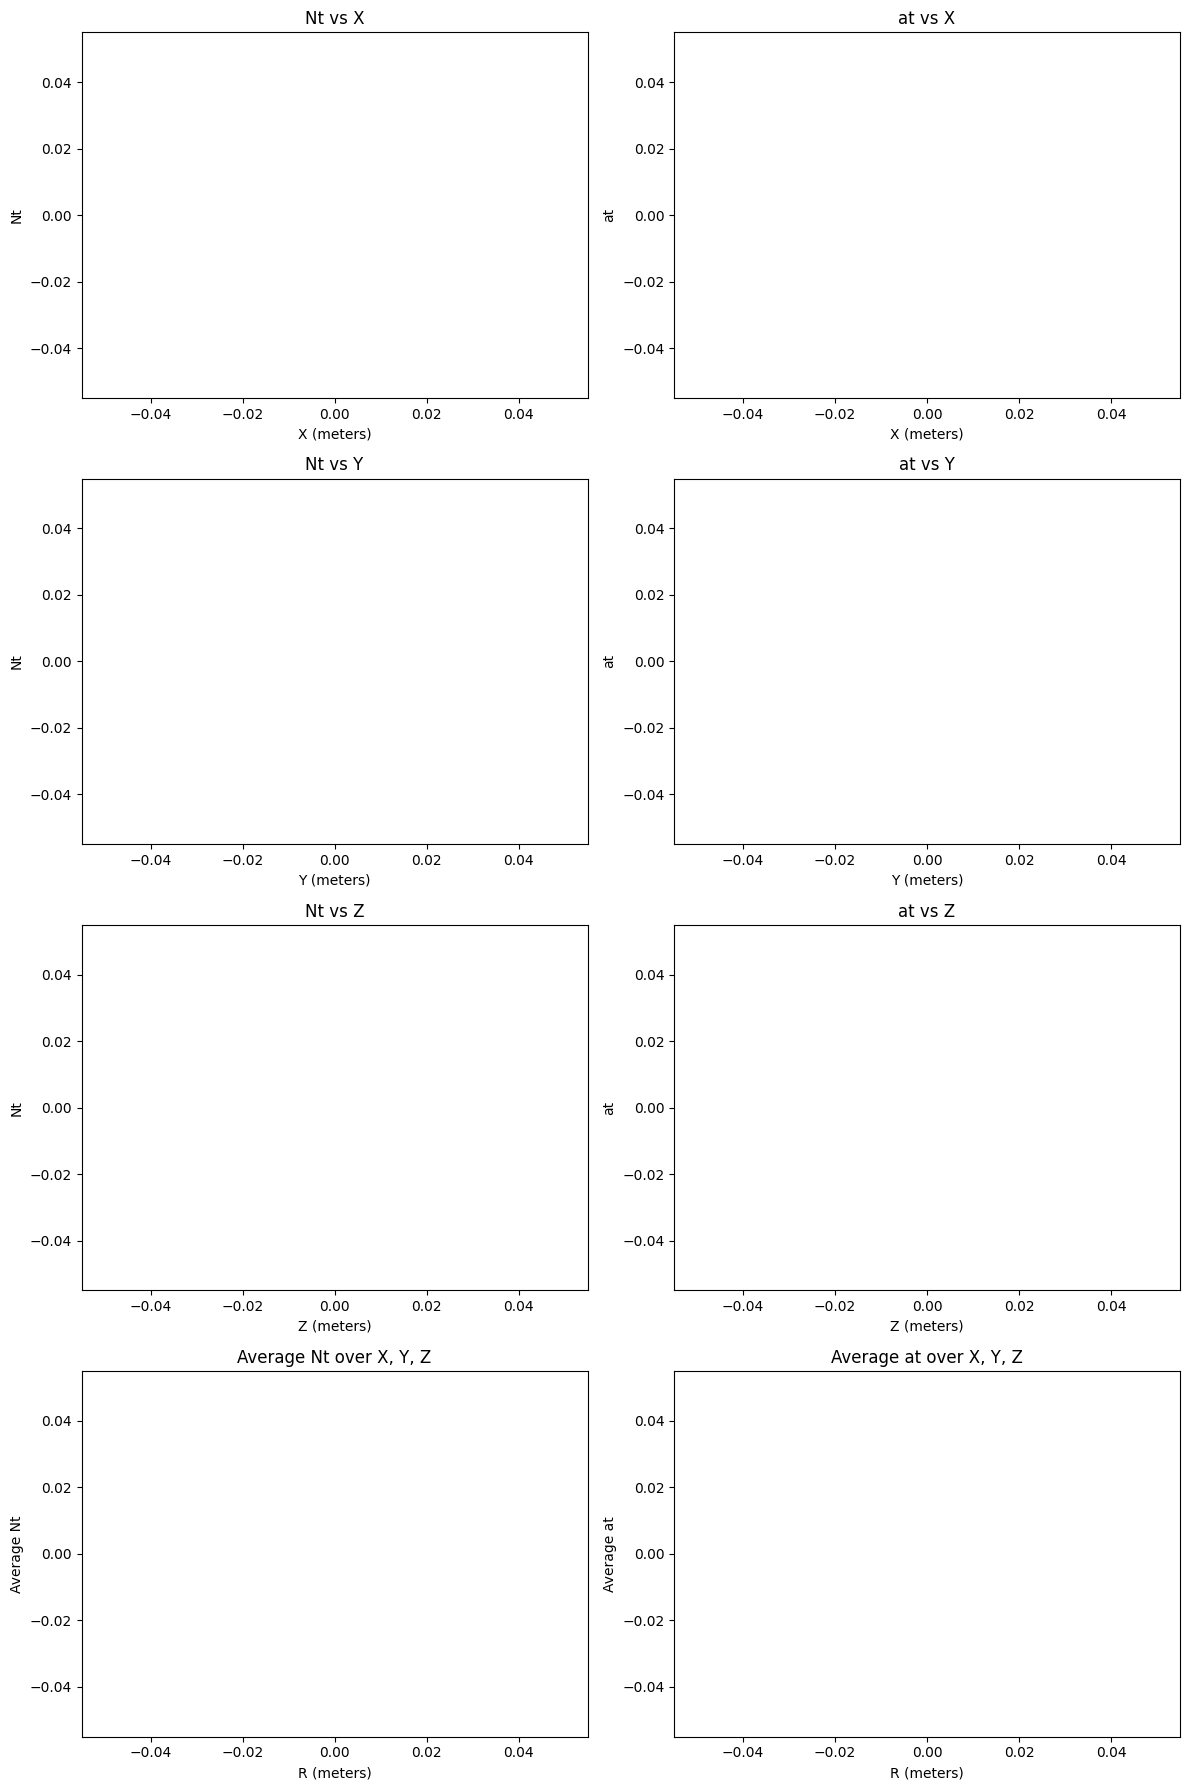

In [ ]:
import numpy as np
from scipy.linalg import eigh
from scipy.interpolate import interp1d
from scipy.optimize import root
import matplotlib.pyplot as plt

# Define constants
omega_x = 2 * np.pi * 83  # Dipole trap frequency in rad/s
omega_y = 2 * np.pi * 51  # Dipole trap frequency in rad/s
omega_z = 2 * np.pi * 53.8  # Dipole trap frequency in rad/s
m = 87 * 1.67e-27  # Mass in kg
hbar = 1.055e-34  # Reduced Planck's constant in J*s
d = 812e-9 / 2  # Lattice spacing in meters
ER = (hbar**2 * np.pi**2) / (2 * m * d**2)  # Recoil energy in Joules
kb = 1.38e-23  # Boltzmann constant in J/K

# Calculate Omega using the provided formula
s = 10  # Lattice depth
trap_frequency_term1 = (4 * ER) / (m * (120e-6)**2)
trap_frequency_term2 = (s / np.sqrt(2)) - np.sqrt(s / 2)
xomega = np.sqrt(trap_frequency_term1 * trap_frequency_term2 + omega_x**2)
yomega = np.sqrt(trap_frequency_term1 * trap_frequency_term2 + omega_y**2)
zomega = np.sqrt(trap_frequency_term1 * trap_frequency_term2 + omega_x**2)
omegax_hz = xomega / (2 * np.pi)  # Convert to Hz

print(f"Omega: {omegax_hz} Hz")

def H(t, U, mu):
    z = 6
    size = 11
    H_matrix = np.zeros((size, size))

    for i in range(size):
        for j in range(size):
            H_matrix[i, j] = (U / 2 * i * (i - 1) - mu * i) * (i == j) - \
                             z * t * ((i + 1 == j) * np.sqrt(j) + (i == j + 1) * np.sqrt(i))

    return H_matrix

def at(t, U, mu, T):
    a = 0.1
    ap = 0.3

    while abs(ap - a) > 1e-3:
        a = ap
        H_matrix = H(t, U, mu)
        vals, states = eigh(H_matrix)
        epsilon = vals

        numerator = 0
        denominator = 0
        for i in range(11):
            for j in range(1, 11):
                numerator += np.sqrt(j) * states[j, i] * states[j-1, i] * np.exp(-epsilon[i] / T)
            denominator += np.exp(-epsilon[i] / T)

        if denominator == 0:
            print(f"Division by zero encountered: t={t}, U={U}, mu={mu}, T={T}, a={a}, numerator={numerator}, denominator={denominator}")
            return np.nan  # Return NaN to indicate an issue

        ap = numerator / denominator

    return ap

def ct(t, U, mu, T):
    optimal_a = at(t, U, mu, T)
    H_matrix = H(t, U, mu)
    vals, states = eigh(H_matrix)

    # Ordering the eigenvalues
    sorted_indices = np.argsort(vals)

    # Returning the sorted eigenvectors
    sorted_eigenvectors = states[:, sorted_indices]

    return sorted_eigenvectors

def nt(t, U, mu, T):
    sorted_eigenvectors = ct(t, U, mu, T)

    # Define the vector b as [0, 1, 2, ..., 10]
    b = np.array([i for i in range(11)])

    # Compute the dot product of b with the square of each column
    result = np.array([np.dot(b, col**2) for col in sorted_eigenvectors.T])

    return result

def epsilon_t(t, U, mu, T):
    optimal_a = at(t, U, mu, T)
    H_matrix = H(t, U, mu)
    vals, states = eigh(H_matrix)

    # Sorting the eigenvalues
    sorted_vals = np.sort(vals)

    return sorted_vals

def Zt(t, U, mu, T):
    epsilon = epsilon_t(t, U, mu, T)

    partition_function = np.sum(np.exp(-epsilon / T))

    return partition_function

def Nt(t, U, mu, T):
    n_t = nt(t, U, mu, T)
    epsilon = epsilon_t(t, U, mu, T)
    Z = Zt(t, U, mu, T)

    result = np.dot(n_t, np.exp(-epsilon / T)) / Z

    return result

def Ut(t, U, mu, T):
    epsilon = epsilon_t(t, U, mu, T)
    Z = Zt(t, U, mu, T)

    result = np.dot(epsilon, np.exp(-epsilon / T)) / Z

    return result

def St(t, U, mu, T):
    Z = Zt(t, U, mu, T)
    U_t = Ut(t, U, mu, T)

    entropy = np.log(Z) + U_t / T

    return entropy

def n0t(t, U, mu, T):
    x = nt(t, U, mu, T)[0]
    if x > 0.01:
        return at(t, U, mu, T)**2 / x
    else:
        return 0

def V(x, y, z):
    return (0.5 * m * (xomega**2 * x**2 + yomega**2 * y**2 + zomega**2 * z**2)) / ER

def nn(t, U, mu, T):
    dr = 3 * d  # Increased step size to reduce number of points
    r_values = np.arange(0, 20e-6, dr)
    sum_value = 0

    for x in r_values:
        for y in r_values:
            for z in r_values:
                effective_mu = mu - V(x, y, z)
                sum_value += Nt(t, U, effective_mu, T)

    result = sum_value / d**3
    return result

def mu_func(t, U, T, num):
    def nn_interp(mu):
        return nn(t, U, mu, T)

    mu_values = np.arange(-0.3, 1.1, 0.2)
    nn_values = [nn_interp(mu) for mu in mu_values]

    interp_func = interp1d(mu_values, nn_values, kind='cubic')

    def equation(mu):
        return interp_func(mu) - num

    result = root(equation, 0.1)
    return result.x[0]

def S_total(t, U, T, num):
    dr = 3 * d  # Increased step size to reduce number of points
    r_values = np.arange(0, 20e-6, dr)
    sum_value = 0

    mu = mu_func(t, U, T, num)
    for x in r_values:
        for y in r_values:
            for z in r_values:
                effective_mu = mu - V(x, y, z)
                sum_value += St(t, U, effective_mu, T)

    result = sum_value / d**3
    return result

def frac(t, U, T, num):
    dr = 3 * d  # Increased step size to reduce number of points
    r_values = np.arange(0, 20e-6, dr)
    sum_value = 0

    mu = mu_func(t, U, T, num)
    for x in r_values:
        for y in r_values:
            for z in r_values:
                effective_mu = mu - V(x, y, z)
                sum_value += at(t, U, effective_mu, T)**2

    result = sum_value / d**3 / nn(t, U, mu, T)
    return result

def en(t, U, T, num):
    dr = 3 * d  # Increased step size to reduce number of points
    r_values = np.arange(0, 20e-6, dr)
    sum_value = 0

    mu = mu_func(t, U, T, num)
    for x in r_values:
        for y in r_values:
            for z in r_values:
                effective_mu = mu - V(x, y, z)
                sum_value += Ut(t, U, effective_mu, T)

    result = sum_value / d**3
    return result

# Example usage
wav = (xomega*yomega*zomega)**(1/3)
t = 0.019
U = 0.28
num = 105 * 10**3
Tc = 4.5*(wav/(2*np.pi *100))*num**(1/3)*10**-9
T = (0.1)**(1/3)*Tc
mu_result = mu_func(t, U, T, num)
mu = mu_result

# Calculate Nt and at squared for each (x, y, z) in r_values
r_values = np.arange(0, 20e-6, 2 * d)  # Increased step size to reduce number of points
Nt_values = np.zeros((len(r_values), len(r_values), len(r_values)))
at_values = np.zeros((len(r_values), len(r_values), len(r_values)))

for i, x in enumerate(r_values):
    for j, y in enumerate(r_values):
        for k, z in enumerate(r_values):
            effective_mu = mu - V(x, y, z)
            Nt_values[i, j, k] = Nt(t, U, effective_mu, T)
            at_values[i, j, k] = at(t, U, effective_mu, T)

# Create slices and average values
mid_index = len(r_values) // 2

Nt_x_slice = Nt_values[mid_index, :, :]
Nt_y_slice = Nt_values[:, mid_index, :]
Nt_z_slice = Nt_values[:, :, mid_index]
Nt_avg = np.mean(Nt_values, axis=(1, 2))

at_x_slice = at_values[mid_index, :, :]
at_y_slice = at_values[:, mid_index, :]
at_z_slice = at_values[:, :, mid_index]
at_avg = np.mean(at_values, axis=(1, 2))

# Plot the results
fig, axs = plt.subplots(4, 2, figsize=(12, 18))

# Nt slices
axs[0, 0].plot(r_values, Nt_values[mid_index, mid_index, :], label='Nt vs X')
axs[0, 0].set_title('Nt vs X')
axs[0, 0].set_xlabel('X (meters)')
axs[0, 0].set_ylabel('Nt')

axs[1, 0].plot(r_values, Nt_values[mid_index, :, mid_index], label='Nt vs Y')
axs[1, 0].set_title('Nt vs Y')
axs[1, 0].set_xlabel('Y (meters)')
axs[1, 0].set_ylabel('Nt')

axs[2, 0].plot(r_values, Nt_values[:, mid_index, mid_index], label='Nt vs Z')
axs[2, 0].set_title('Nt vs Z')
axs[2, 0].set_xlabel('Z (meters)')
axs[2, 0].set_ylabel('Nt')

axs[3, 0].plot(r_values, Nt_avg, label='Nt vs Average of X, Y, Z')
axs[3, 0].set_title('Average Nt over X, Y, Z')
axs[3, 0].set_xlabel('R (meters)')
axs[3, 0].set_ylabel('Average Nt')

# at slices
axs[0, 1].plot(r_values, at_values[mid_index, mid_index, :], label='at vs X')
axs[0, 1].set_title('at vs X')
axs[0, 1].set_xlabel('X (meters)')
axs[0, 1].set_ylabel('at')

axs[1, 1].plot(r_values, at_values[mid_index, :, mid_index], label='at vs Y')
axs[1, 1].set_title('at vs Y')
axs[1, 1].set_xlabel('Y (meters)')
axs[1, 1].set_ylabel('at')

axs[2, 1].plot(r_values, at_values[:, mid_index, mid_index], label='at vs Z')
axs[2, 1].set_title('at vs Z')
axs[2, 1].set_xlabel('Z (meters)')
axs[2, 1].set_ylabel('at')

axs[3, 1].plot(r_values, at_avg, label='at vs Average of X, Y, Z')
axs[3, 1].set_title('Average at over X, Y, Z')
axs[3, 1].set_xlabel('R (meters)')
axs[3, 1].set_ylabel('Average at')

plt.tight_layout()
plt.show()
